In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error


# Load data
df = pd.read_csv("/Users/inayasiddiqui/Documents/Math6243FinalProject/Biodiversity-Predictors/data/processed/marine_data_cleaned.csv")

print(df.head())
print(df.shape)

# Single target variable
y = df["log_richness"]

# Separate features
# Drop the raw response column and ID column
X = df.drop(columns=["log_richness", "species_richness", "STUDY_ID"], errors="ignore")

def prepare_features(X):
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

    X_cat = pd.get_dummies(X[cat_cols], drop_first=True)
    X_final = pd.concat([X[num_cols], X_cat], axis=1)

    return X_final, num_cols, cat_cols

# Prepare feature matrix
X_final, num_cols, cat_cols = prepare_features(X)

print("\nFeature matrix shape:", X_final.shape)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

# Scale numeric columns
scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Convert to arrays if desired
X_train_scaled = X_train.values
X_test_scaled = X_test.values

print("\nTraining set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)


def run_regularized_models(X_train, X_test, y_train, y_test, label="Target"):
    results = []

    # Ridge
    ridge = Ridge()
    ridge_param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}
    ridge_cv = GridSearchCV(ridge, ridge_param_grid, cv=5, scoring="r2")
    ridge_cv.fit(X_train, y_train)

    ridge_pred = ridge_cv.predict(X_test)
    results.append({
        "Target": label,
        "Model": "Ridge",
        "Best_Params": ridge_cv.best_params_,
        "R2": r2_score(y_test, ridge_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, ridge_pred))
    })

    # Lasso
    lasso = Lasso(max_iter=100000)
    lasso_param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10]}
    lasso_cv = GridSearchCV(lasso, lasso_param_grid, cv=5, scoring="r2")
    lasso_cv.fit(X_train, y_train)

    lasso_pred = lasso_cv.predict(X_test)
    results.append({
        "Target": label,
        "Model": "Lasso",
        "Best_Params": lasso_cv.best_params_,
        "R2": r2_score(y_test, lasso_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, lasso_pred))
    })

    # ElasticNet
    elastic = ElasticNet(max_iter=100000)
    elastic_param_grid = {
        "alpha": [0.001, 0.01, 0.1, 1],
        "l1_ratio": [0.2, 0.5, 0.8]
    }
    elastic_cv = GridSearchCV(elastic, elastic_param_grid, cv=5, scoring="r2")
    elastic_cv.fit(X_train, y_train)

    elastic_pred = elastic_cv.predict(X_test)
    results.append({
        "Target": label,
        "Model": "ElasticNet",
        "Best_Params": elastic_cv.best_params_,
        "R2": r2_score(y_test, elastic_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, elastic_pred))
    })

    print(f"\n--- Results for {label} ---")
    for row in results:
        print(f"{row['Model']}:")
        print("  Best params:", row["Best_Params"])
        print("  R²:", round(row["R2"], 4))
        print("  RMSE:", round(row["RMSE"], 4))

    return pd.DataFrame(results), ridge_cv, lasso_cv, elastic_cv


# Run models for the single target
results_log_richness, ridge_cv, lasso_cv, elastic_cv = run_regularized_models(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    label="log_richness"
)

print("\nSummary of results:")
print(results_log_richness)

   STUDY_ID  LATITUDE  LONGITUDE  species_richness  total_abundance  \
0       164  37.81020 -122.32300                13            126.0   
1       245  50.85045    3.61936                 9             50.0   
2       245  50.88528    3.69284                 6             49.0   
3       245  50.91131    3.41330                15           1106.0   
4       245  50.91145    3.41317                15            420.0   

   mean_depth  n_samples  n_years  year_start  year_end  ... precip_proxy  \
0    1.000000          3        2        2000      2001  ...  1463.318708   
1   -6.267057          6        2        2009      2010  ...  1133.244839   
2   -6.267057          3        2        2009      2010  ...  1311.765920   
3   -6.267057         15        2        2007      2008  ...  1330.386822   
4   -6.267057         15        2        2007      2008  ...  1041.224731   

   log_area sampling_intensity  depth_category  coastal_proxy  temp_squared  \
0  2.944439                1.5 

In [8]:
# Coefficients for log_richness
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Ridge": ridge_cv.best_estimator_.coef_,
    "Lasso": lasso_cv.best_estimator_.coef_,
    "ElasticNet": elastic_cv.best_estimator_.coef_
})

print("\nTop predictors for log_richness:")
print(
    coef_df
    .sort_values(by="Lasso", key=np.abs, ascending=False)
    .head(20)
)


Top predictors for log_richness:
                       Feature     Ridge         Lasso  ElasticNet
26                hemisphere_S  1.181349  1.131342e+00    1.132508
22            latitude_squared  0.355905  6.945307e-01    0.703508
24           climate_Temperate -0.648247 -6.743081e-01   -0.669382
5                      n_years  0.461045  6.632318e-01    0.664752
17                    log_area -0.619988 -6.295610e-01   -0.628083
1                    LONGITUDE  0.430463  4.235652e-01    0.424782
25  climate_Temperate/Tropical  0.333860  2.810865e-01    0.289503
8                   AREA_SQ_KM -0.273452 -2.609573e-01   -0.262989
4                    n_samples  0.146482  1.509139e-01    0.150332
20                temp_squared  0.299634  1.366353e-01    0.140371
18          sampling_intensity  0.073533  6.545424e-02    0.066592
3                   mean_depth -0.062051 -5.897833e-02   -0.059789
11                    tropical  0.025789  5.418439e-02    0.045100
2              total_abundan

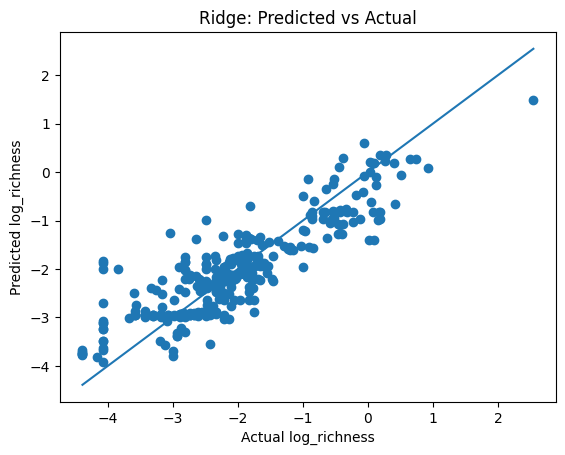

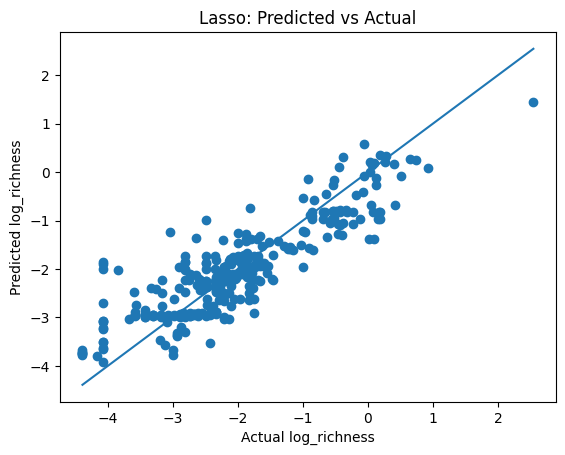

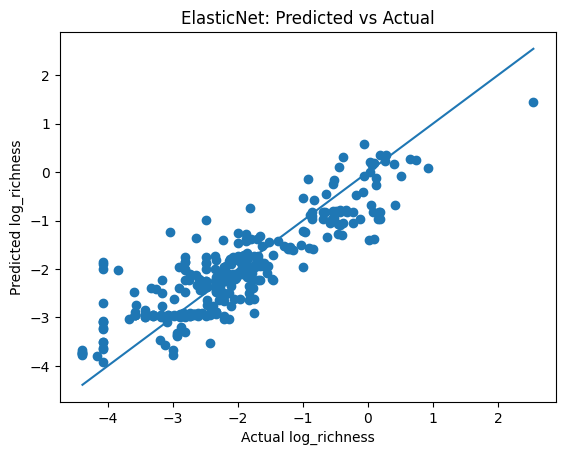

In [11]:
import matplotlib.pyplot as plt

def plot_predictions(y_test, y_pred, model_name):
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()])  # perfect line
    plt.xlabel("Actual log_richness")
    plt.ylabel("Predicted log_richness")
    plt.title(f"{model_name}: Predicted vs Actual")
    plt.show()

ridge_pred = ridge_cv.predict(X_test_scaled)
lasso_pred = lasso_cv.predict(X_test_scaled)
elastic_pred = elastic_cv.predict(X_test_scaled)

plot_predictions(y_test, ridge_pred, "Ridge")
plot_predictions(y_test, lasso_pred, "Lasso")
plot_predictions(y_test, elastic_pred, "ElasticNet")

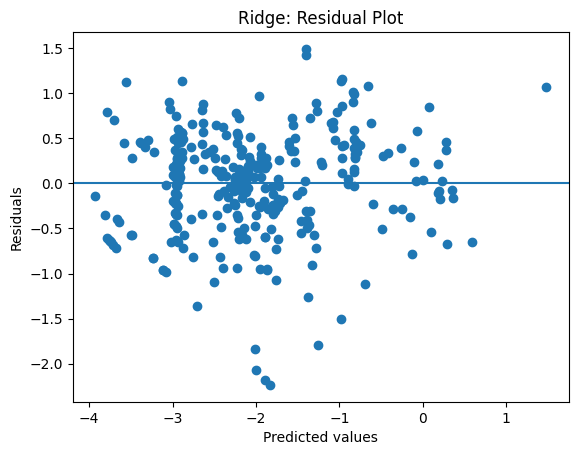

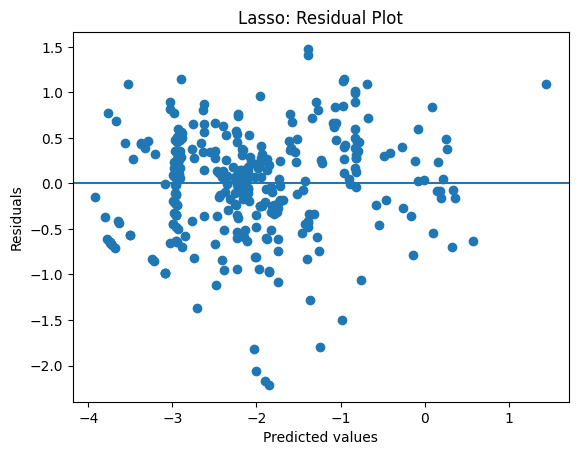

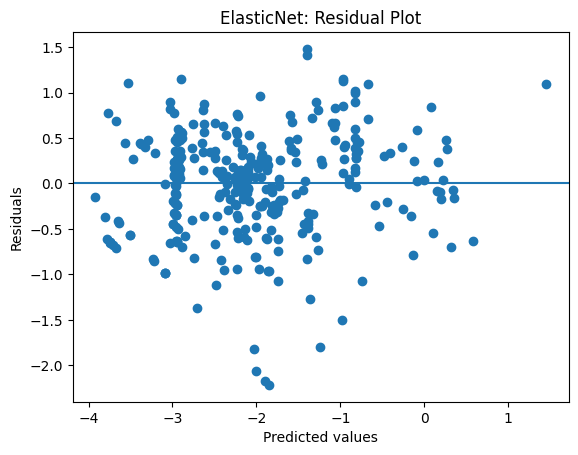

In [12]:
def plot_residuals(y_test, y_pred, model_name):
    residuals = y_test - y_pred

    plt.figure()
    plt.scatter(y_pred, residuals)
    plt.axhline(y=0)
    plt.xlabel("Predicted values")
    plt.ylabel("Residuals")
    plt.title(f"{model_name}: Residual Plot")
    plt.show()

plot_residuals(y_test, ridge_pred, "Ridge")
plot_residuals(y_test, lasso_pred, "Lasso")
plot_residuals(y_test, elastic_pred, "ElasticNet")

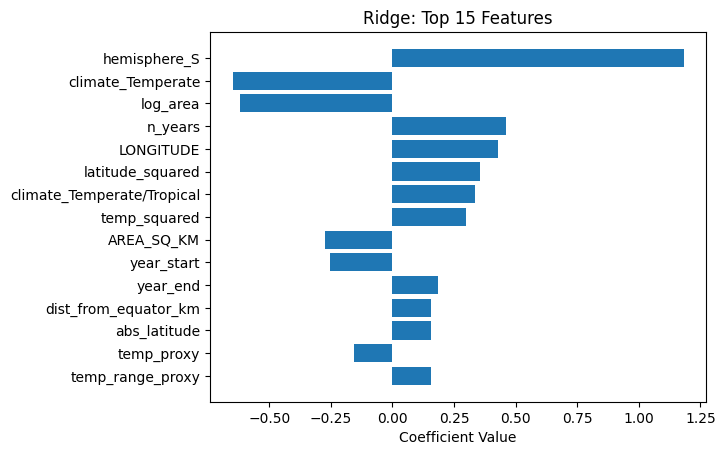

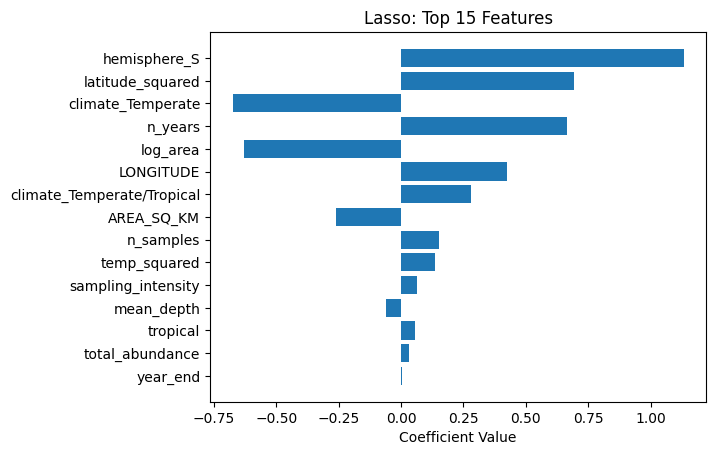

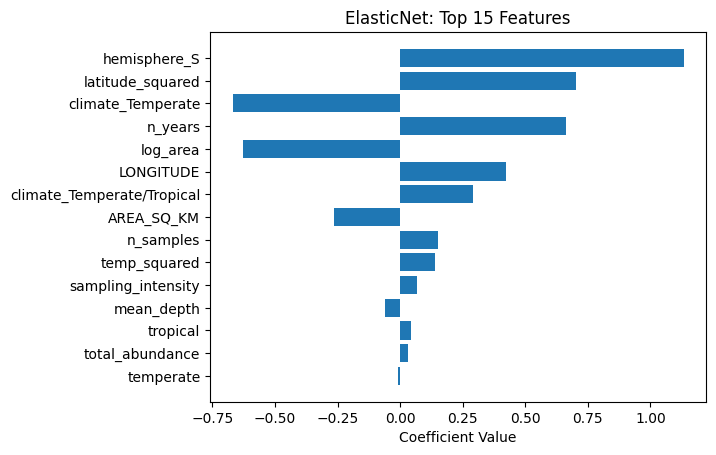

In [13]:
def plot_coefficients(coef_df, model_name, top_n=15):
    coef_sorted = coef_df.copy()
    coef_sorted["abs_val"] = coef_sorted[model_name].abs()
    coef_sorted = coef_sorted.sort_values("abs_val", ascending=False).head(top_n)

    plt.figure()
    plt.barh(coef_sorted["Feature"], coef_sorted[model_name])
    plt.xlabel("Coefficient Value")
    plt.title(f"{model_name}: Top {top_n} Features")
    plt.gca().invert_yaxis()
    plt.show()

plot_coefficients(coef_df, "Ridge")
plot_coefficients(coef_df, "Lasso")
plot_coefficients(coef_df, "ElasticNet")